# Camera-pose alignment spike: tie-point correction for the real-WAC overlay

`image_generation.ipynb`'s Phase 6B overlay (the real, ISIS-processed WAC crop mapprojected onto
the basemap) is visibly not perfectly aligned with it -- small, "not huge" per direct user
observation, but real. This notebook is the checked-in, reproducible form of the investigation
into that (see `docs/plan.md`'s open items, "camera-pose alignment", for the full research trail:
why ASP's `bundle_adjust`/`pc_align`/`image_align` and ISIS's own `jigsaw`+`findfeatures` routes
both hit real blockers, and `docs/history.md`'s dated entries for how this notebook's own approach
was arrived at). **Not a finished, validated pipeline feature** -- this stays on its own branch,
not wired into `image_generation.py`'s main pipeline, until the approach is validated further.

The approach, implemented in `src/trntest/pose_alignment.py`: feature-match the already
map-projected WAC crop directly against the basemap (both already in the same map projection, no
camera model needed for the matching step itself), fit a similarity transform (translation +
rotation + uniform scale) from the matches via RANSAC, apply it to the WAC raster's own
georeferencing, and compare the result against the basemap via the *existing*,
unmodified `plotting.plot_overlay_toggle` blink comparator.

Similarity, not a richer model: deliberately the simplest plausible correction to start from, not
asserted as physically "correct" -- a real camera pose error has 6 degrees of freedom before even
accounting for this being a pushframe sensor's extended-exposure capture, and the mapping from
those onto a 2D map-space distortion isn't simple or one-to-one, so there's no first-principles
case that any fixed DOF count is exactly right. See `fit_similarity_correction`'s own docstring.

In [1]:
import numpy as np
import rasterio

import trntest
from trntest import isis_wac, plotting, pose_alignment

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()
dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
dataset.populate(limit=1)
entry = dataset[0]

# The real public function TrnTestCropImage._mapprojected_path() itself calls -- used directly here
# rather than that private method, which isn't meant for callers outside the class.
wac_path = isis_wac.run_cam2map_for_crop(entry.crop_result, entry.dem_ortho_result, entry.per_image_config)
basemap_path = entry.dem_ortho_result.ortho
print("WAC mapprojected crop:", wac_path)
print("Basemap ortho:", basemap_path)

ROI center (lon,lat deg): (np.float64(171.92947682091), np.float64(55.719720074809004)), bbox (local m): (-131365.73093080937, -131673.71345972817, 143948.32342712246, 145499.38432747885)
ROI size 2753x2772 px (~100.0 m/px)


WAC mapprojected crop: /workspace/scratch/isis_wac/M1327210646CE/M1327210646CE.vis.cal.stitched.crop-cam2map.tif
Basemap ortho: /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc.tif


## Crop the basemap to the WAC's own footprint, and prepare both for matching

The basemap ortho covers a much larger area than the WAC crop's own real footprint -- cropping to
match (`pose_alignment.crop_to_footprint`, padded 15%) gives the feature matcher a far smaller,
more relevant search space; confirmed empirically to matter for match quality, not just compute.
`to_uint8_for_matching` converts each raster to 8-bit (OpenCV's feature detectors can't even load
a raw float32 GeoTIFF), stretching over valid pixels only.

In [2]:
basemap_cropped_path = pose_alignment.crop_to_footprint(
    basemap_path, wac_path, entry.per_image_config.output_dir / "alignment" / "basemap_cropped.tif"
)
wac_image, wac_valid = pose_alignment.to_uint8_for_matching(wac_path)
basemap_image, basemap_valid = pose_alignment.to_uint8_for_matching(basemap_cropped_path)
print(f"WAC: {wac_image.shape}, valid {wac_valid.mean():.1%}")
print(f"Basemap: {basemap_image.shape}, valid {basemap_valid.mean():.1%}")

WAC: (1839, 1709), valid 71.4%
Basemap: (2087, 2106), valid 100.0%


## Feature matching

SIFT on Sobel-filtered versions of each image (see `pose_alignment.match_features`'s docstring for
why: raw-intensity matching across two different sensors/processing pipelines -- real calibrated
WAC I/F vs. a synthetic basemap render -- is far less reliable than matching on edge/gradient
content, which is more consistent across that gap), with a mutual ratio test and two RANSAC
geometric-consistency passes (homography, then epipolar).

In [3]:
basemap_points_px, wac_points_px = pose_alignment.match_features(basemap_image, basemap_valid, wac_image, wac_valid)
print(f"{len(basemap_points_px)} matched points survived ratio/symmetry/RANSAC verification")

106 matched points survived ratio/symmetry/RANSAC verification


Converting both point sets to real map coordinates (`pose_alignment.pixel_points_to_map`) --
necessary since the WAC crop and the cropped basemap are different windows with different pixel
origins, even though they share a CRS/scale -- lets us look at the real-world offset each match
implies. High scatter here (relative to the mean) is a sign the match set is a mix of real
correspondences and false positives, not a single clean, trustworthy correction on its own.

In [4]:
with rasterio.open(basemap_cropped_path) as src:
    basemap_transform = src.transform
with rasterio.open(wac_path) as src:
    wac_transform = src.transform

basemap_points_map = pose_alignment.pixel_points_to_map(basemap_points_px, basemap_transform)
wac_points_map = pose_alignment.pixel_points_to_map(wac_points_px, wac_transform)

raw_offsets_m = wac_points_map - basemap_points_map
raw_distances_m = np.linalg.norm(raw_offsets_m, axis=1)
print(f"Raw offset distance: mean {raw_distances_m.mean():.0f}m, std {raw_distances_m.std():.0f}m")
print(f"Range: {raw_distances_m.min():.0f}m - {raw_distances_m.max():.0f}m")

Raw offset distance: mean 725m, std 340m
Range: 185m - 1404m


## Fit the pose correction

`fit_similarity_correction` maps the WAC's own (possibly-wrong) claimed positions onto the
basemap's trusted ones, with its own internal RANSAC separating real, consistent correspondences
from outliers -- report both, not just the inliers, since how bad the rejected points really are
is itself useful information about match-set quality.

In [5]:
correction, inliers, residuals_m = pose_alignment.fit_similarity_correction(wac_points_map, basemap_points_map)

scale = np.sqrt(correction.a**2 + correction.d**2)
rotation_deg = np.degrees(np.arctan2(correction.d, correction.a))
print(f"Inliers: {inliers.sum()} / {len(inliers)}")
print(
    f"Fitted scale: {scale:.4f}  rotation: {rotation_deg:.3f} deg  translation: ({correction.c:.1f}, {correction.f:.1f}) m"
)
print(f"Inlier residuals: mean {residuals_m[inliers].mean():.0f}m, max {residuals_m[inliers].max():.0f}m")
if (~inliers).any():
    print(f"Outlier residuals (if forced to fit): mean {residuals_m[~inliers].mean():.0f}m")

Inliers: 53 / 106
Fitted scale: 0.9953  rotation: 0.459 deg  translation: (-369.1, -548.8) m
Inlier residuals: mean 145m, max 305m
Outlier residuals (if forced to fit): mean 651m


## Apply the correction and compare via the existing blink overlay

`apply_correction` composes the fitted transform with the WAC raster's own georeferencing and
resamples back onto its original grid, so it drops straight into the *existing*
`plotting.plot_overlay_toggle` blink comparator with no further plumbing changes -- both the
uncorrected and corrected overlays are shown below for direct comparison. A blink comparator is
the right tool for judging a shift this small (a few pixels): far more sensitive than a static
side-by-side crop.

In [6]:
corrected_wac_path = pose_alignment.apply_correction(
    wac_path, correction, entry.per_image_config.output_dir / "alignment" / "wac_corrected.tif"
)


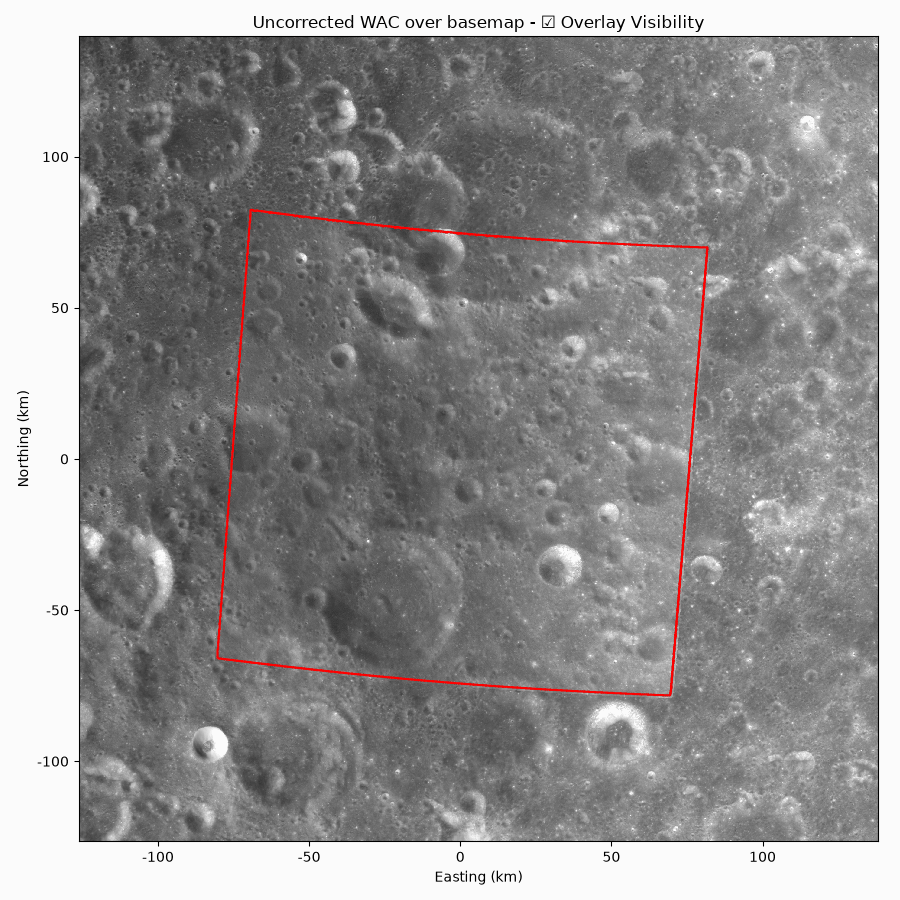

In [7]:
plotting.plot_overlay_toggle(basemap_path, wac_path, title="Uncorrected WAC over basemap")


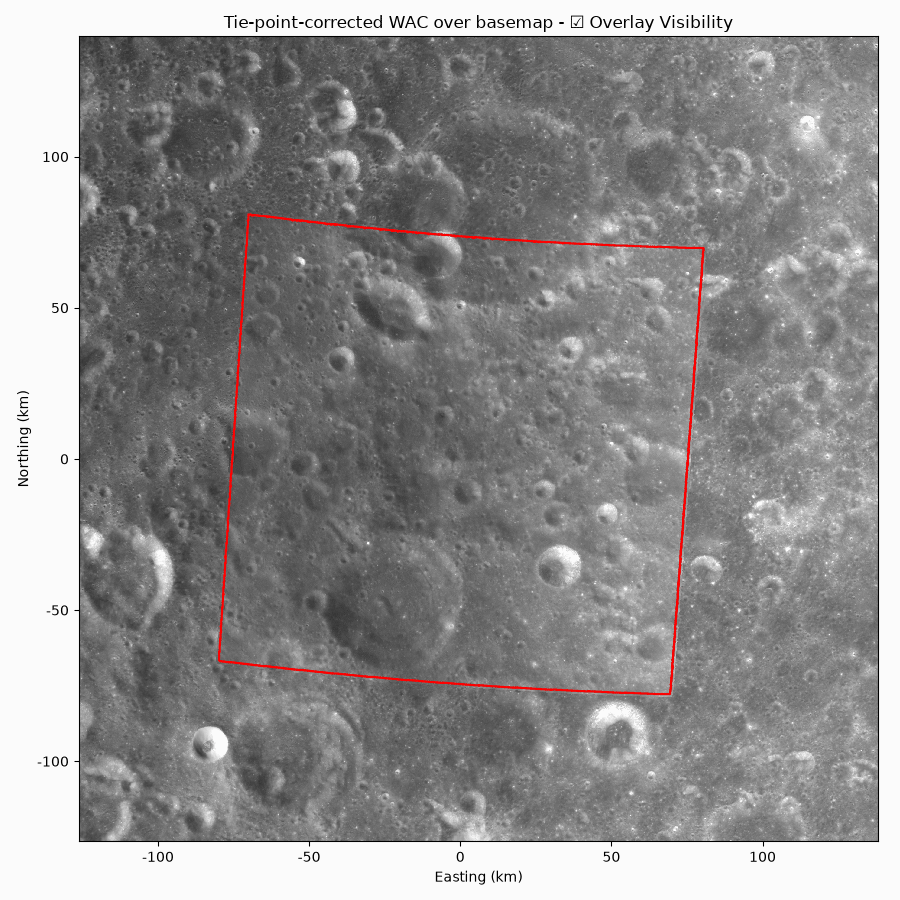

In [8]:
plotting.plot_overlay_toggle(basemap_path, corrected_wac_path, title="Tie-point-corrected WAC over basemap")